In [1]:
print(1+1)

2


In [2]:
import tensorflow as tf
import cv2


In [3]:
pdf_path =r"OCD\data\recreated_kaithi.pdf"

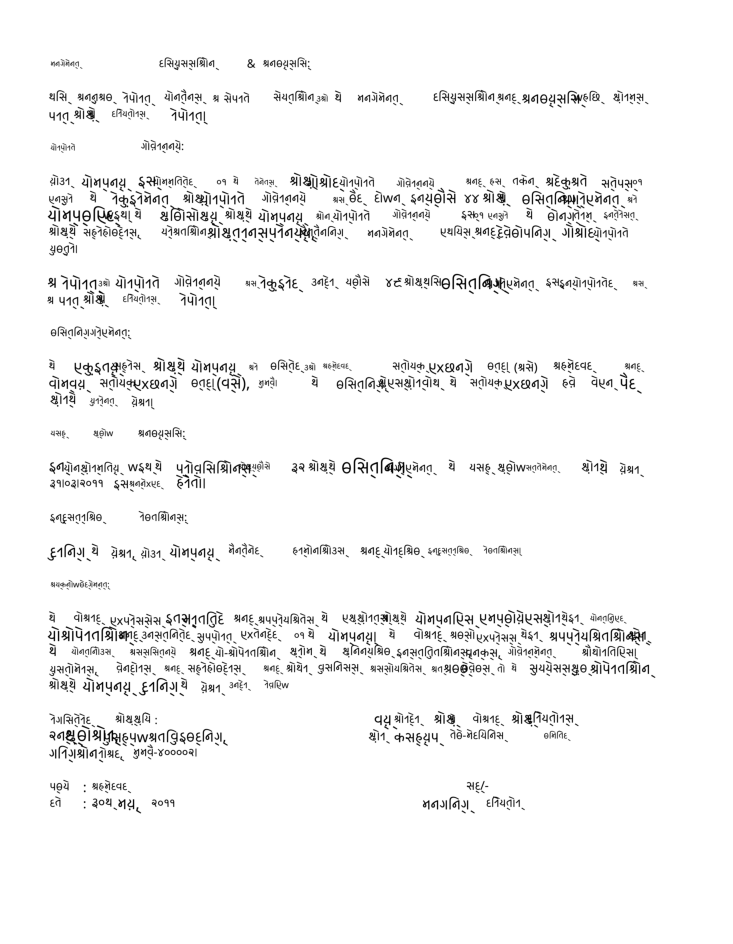

In [5]:
import numpy as np

import fitz  # PyMuPDF
import matplotlib.pyplot as plt

doc = fitz.open(pdf_path)
page = doc.load_page(5)  # first page (0-based index)
pix = page.get_pixmap(dpi=150)

img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
if pix.n == 4:  # RGBA -> RGB for display
    img = img[:, :, :3]

plt.figure(figsize=(10, 12))
plt.imshow(img)
plt.axis("off")
plt.show()

doc.close()

In [8]:
import pytesseract

# If you meant OCR (text extraction) on the existing `img` variable:
# try:
# except ImportError:
#     raise ImportError("Install pytesseract first: pip install pytesseract")

# Preprocess image for better OCR
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
gray = cv2.GaussianBlur(gray, (3, 3), 0)
_, bin_img = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# OCR
text = pytesseract.image_to_string(bin_img, lang="eng")

print("Extracted text:\n")
print(text)

# Optional: save output
with open("ocr_output.txt", "w", encoding="utf-8") as f:
    f.write(text)

TesseractNotFoundError: tesseract is not installed or it's not in your PATH. See README file for more information.